## Task 3: Regional Climate Synthesis & Vulnerability Ranking
### Challenge Overview
This analysis synthesizes climate data from Ethiopia, Kenya, Sudan, Tanzania, and Nigeria (2015–2026). The objective is to identify regional climate stressors and provide a data-driven foundation for Ethiopia’s position at the COP32 climate summit.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

countries = ['ethiopia', 'kenya', 'sudan', 'tanzania', 'nigeria']
df_list = []

for country in countries:
    temp_df = pd.read_csv(f"../data/{country}_clean.csv")
    temp_df['Country'] = country.capitalize()
    df_list.append(temp_df)

all_data = pd.concat(df_list, ignore_index=True)
all_data['DATE'] = pd.to_datetime(all_data['DATE'])

### Temperature Trend Comparison (2015-2026) and Summary table 
The following chart visualizes the monthly average temperature ($T2M$) across the five nations, highlighting seasonal peaks and regional baselines and a Summary table comparing mean, median, and standard deviation of T2M across countries.

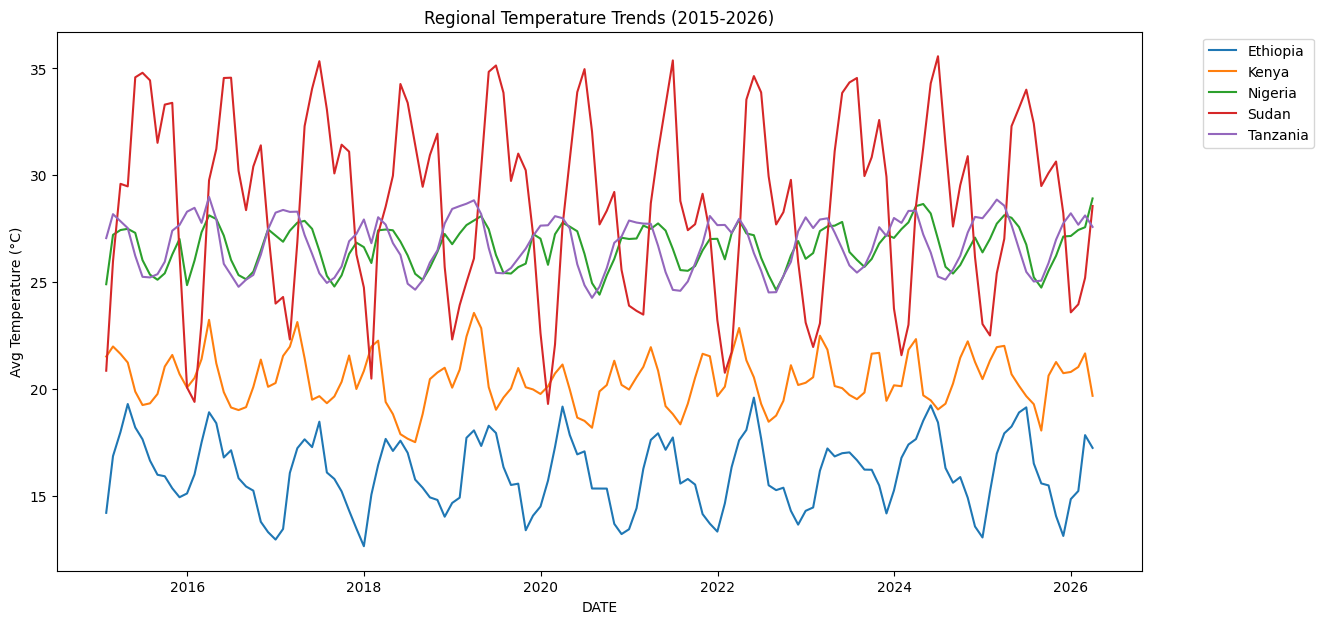

Temperature Summary Statistics:


,mean,median,std
Country,,,
Ethiopia,16.07,16.04,1.90
Kenya,20.43,20.36,1.44
Nigeria,26.66,26.82,1.12
Sudan,28.76,29.16,4.68
Tanzania,26.80,26.99,1.33


In [ ]:
plt.figure(figsize=(14, 7))
monthly_comp = all_data.set_index('DATE').groupby('Country').resample('ME')['T2M'].mean().reset_index()

sns.lineplot(data=monthly_comp, x='DATE', y='T2M', hue='Country')
plt.title("Regional Temperature Trends (2015-2026)")
plt.ylabel("Avg Temperature (°C)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

t2m_summary = all_data.groupby('Country')['T2M'].agg(['mean', 'median', 'std']).round(2)
print("Temperature Summary Statistics:")
display(t2m_summary)

## Precipitation Variability Comparison and Summary Statistics
RainfallBoxplots represent the daily precipitation ($PRECTOTCORR$) distribution. Outliers indicate extreme rainfall events and potential flood risks and a Summary table comparing mean, median, and standard deviation of PRECTOTCORR across countries.

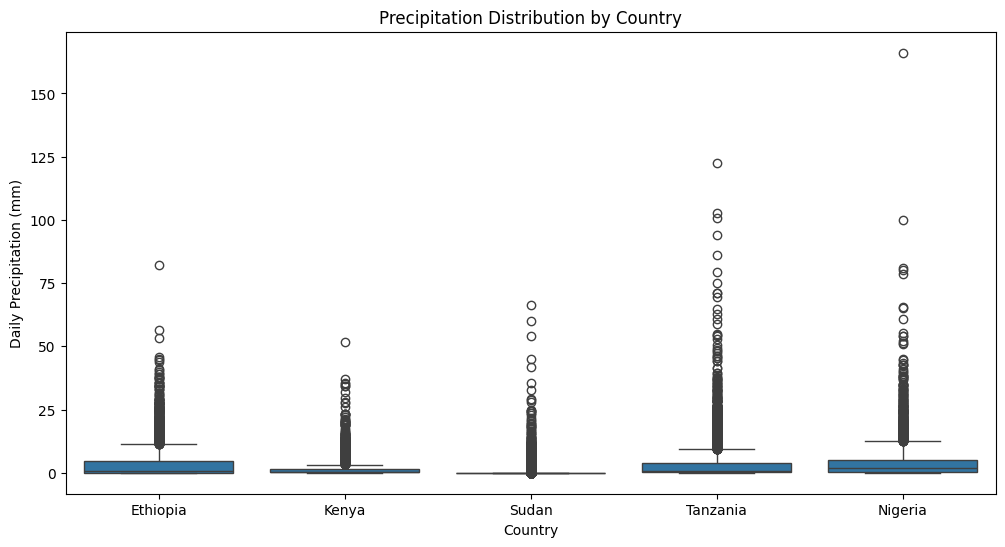

Precipitation Summary Statistics:


,mean,median,std
Country,,,
Ethiopia,3.63,0.82,6.29
Kenya,1.47,0.38,3.18
Nigeria,4.21,1.84,7.27
Sudan,0.64,0.00,3.06
Tanzania,3.74,0.64,8.00


In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=all_data, x='Country', y='PRECTOTCORR')
plt.title("Precipitation Distribution by Country")
plt.ylabel("Daily Precipitation (mm)")
plt.show()

precip_summary = all_data.groupby('Country')['PRECTOTCORR'].agg(['mean', 'median', 'std']).round(2)
print("Precipitation Summary Statistics:")
display(precip_summary)

### Extreme Event Frequency
- Annual Extreme Heat (>35°C) & Dry Spells (<1mm)
These metrics highlight the frequency of dangerous thermal conditions and the duration of chronic water scarcity.

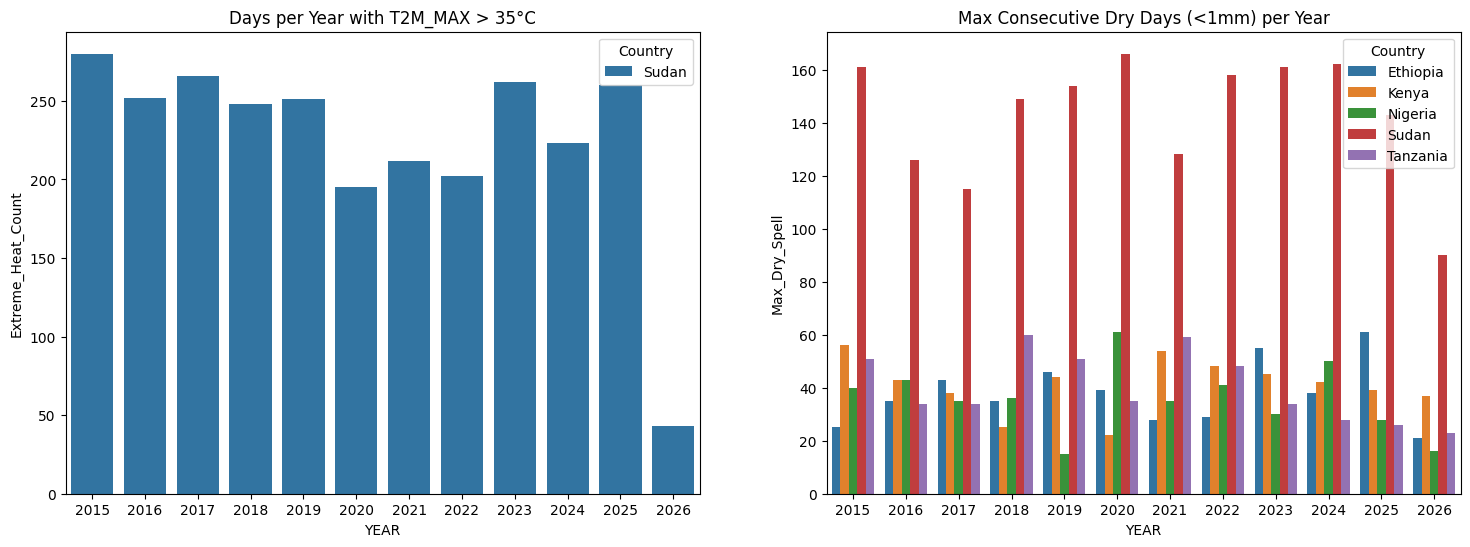

In [ ]:
heat_days = all_data[all_data['T2M_MAX'] > 35].groupby(['Country', 'YEAR']).size().reset_index(name='Extreme_Heat_Count')

def get_max_dry_spell(series):
    is_dry = series < 1
    return is_dry.groupby((is_dry != is_dry.shift()).cumsum()).sum().max()

dry_spells = all_data.groupby(['Country', 'YEAR'])['PRECTOTCORR'].apply(get_max_dry_spell).reset_index(name='Max_Dry_Spell')

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.barplot(data=heat_days, x='YEAR', y='Extreme_Heat_Count', hue='Country', ax=axes[0])
axes[0].set_title("Days per Year with T2M_MAX > 35°C")

sns.barplot(data=dry_spells, x='YEAR', y='Max_Dry_Spell', hue='Country', ax=axes[1])
axes[1].set_title("Max Consecutive Dry Days (<1mm) per Year")
plt.show()

### Statistical Significance (ANOVA)
To validate the observed differences in regional temperatures, a One-Way ANOVA was performed:

- F-Statistic: $18938.75$
- p-value: $0.0000e+00$

Conclusion: The $p < 0.05$ indicates that the climatic differences between these countries are statistically significant, justifying unique adaptation strategies for each nation.

In [ ]:
groups = [all_data[all_data['Country'] == c.capitalize()]['T2M'] for c in countries]
f_stat, p_val = stats.f_oneway(*groups)

print(f"ANOVA F-statistic: {f_stat:.2f}")
print(f"ANOVA p-value: {p_val:.4e}")



ANOVA F-statistic: 18938.75
ANOVA p-value: 0.0000e+00


'\nIf p-value < 0.05: The differences in temperature across these countries are \nstatistically significant and not due to random chance. This justifies unique \nclimate adaptation strategies for each nation.\n'

### Data-Driven Vulnerability Ranking 

| Rank | Country | Heat Risk | Drought Risk | Precip Instability ($std$) | Overall Vulnerability |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **1** | **Sudan** | Critical | Extreme | Low (Arid baseline) | **Highest** |
| **2** | **Nigeria** | High | Moderate | High (7.27) | **High** |
| **3** | **Tanzania** | Moderate | Low | Highest (8.00) | **Moderate-High** |
| **4** | **Kenya** | Moderate | High | Moderate | **Moderate** |
| **5** | **Ethiopia** | Lowest | Moderate | Moderate (6.29) | **Moderate-Low** |


### COP32 Position Paper: Key Observations

- Regional Warming Epicenter: Sudan is warming at the most alarming rate, consistently maintaining the highest baseline temperatures and peaking near 35°C monthly averages. This trend suggests an imminent threat to human habitability and livestock survival in the Sahelian belt.

- Precipitation Instability: Tanzania exhibits the most unstable precipitation patterns, with the highest standard deviation (8.00). While Nigeria has a higher mean rainfall, Tanzania’s variability suggests a greater risk of unpredictable "flash-to-drought" cycles that disrupt traditional agricultural planning.

- Climate Stress Indicators: The frequency of extreme heat in Sudan (exceeding 250 days/year above 35°C) coupled with consecutive dry spells lasting over 160 days reveals a state of permanent climate stress. This data proves that for certain neighbors, climate change is no longer a "future threat" but a daily operational limit.

- Ethiopia’s Comparative Profile: Compared to its neighbors, Ethiopia maintains the most moderate thermal profile (averaging ~13-19°C), likely due to its high-altitude topography. However, Ethiopia’s precipitation $std$ (6.29) is significantly higher than Kenya’s, indicating that while Ethiopia is cooler, it faces much higher flood and erosion risks than its southern neighbor.

- Priority Finance Champion: Ethiopia should champion Sudan for priority climate finance at COP32. The data is indisputable: Sudan faces the highest heat-drought compound risk in the region. Supporting Sudan's case not only addresses the most urgent humanitarian risk but also stabilizes the region against climate-induced migration that could impact Ethiopia’s borders.
